# Chapter 2
Obs: This notebook has solutions to problems proposed by a brazilian book which, I believe, hardly will be translated to english. That's why all answers are in brazilian portuguese.

In [1]:
from ipywidgets import interact
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path=os.path.join(os.getcwd(),".env"))

False

## Exemplos

### Ex. 1

In [54]:
data = dict(
    tipo=["A+", "A-", "B+", "B-", "AB+", "AB-", "0+", "0-"],
    doadores=[15, 2, 6, 1, 1, 1, 32, 2]
)
df = pd.DataFrame(data=data)
df["frequencia_absoluta"] = df.doadores
df["frequencia_acumulada"] = df.frequencia_absoluta.cumsum()
df["frequencia_relativa"] = df["frequencia_absoluta"]/df.frequencia_absoluta.sum()
df["frequencia_relativa_acumulada"] = df.frequencia_relativa.cumsum()
df

,tipo,doadores,frequencia_absoluta,frequencia_acumulada,frequencia_relativa,frequencia_relativa_acumulada
0,A+,15,15,15,0.250000,0.250000
1,A-,2,2,17,0.033333,0.283333
2,B+,6,6,23,0.100000,0.383333
3,B-,1,1,24,0.016667,0.400000
4,AB+,1,1,25,0.016667,0.416667
5,AB-,1,1,26,0.016667,0.433333
6,0+,32,32,58,0.533333,0.966667
7,0-,2,2,60,0.033333,1.000000


### Ex.2

In [74]:
data = dict(
    clientes=[
        2,5,4,7,4,1,6,2,2,5,
        4,12,8,6,4,5,2,8,2,6,
        4,7,2,5,6,4,1,5,10,2,
        2,10,6,4,3,4,6,3,8,4
    ]
)
df = pd.DataFrame(data=data)
df = df.groupby(["clientes"]).agg(frequencia_absoluta=pd.NamedAgg(column="clientes", aggfunc="count"))
df["frequencia_acumulada"] = df.frequencia_absoluta.cumsum()
df["frequencia_relativa"] = df["frequencia_absoluta"]/df.frequencia_absoluta.sum()
df["frequencia_relativa_acumulada"] = df.frequencia_relativa.cumsum()
df

,frequencia_absoluta,frequencia_acumulada,frequencia_relativa,frequencia_relativa_acumulada
clientes,,,,
1,2,2,0.050,0.050
2,8,10,0.200,0.250
3,2,12,0.050,0.300
4,9,21,0.225,0.525
5,5,26,0.125,0.650
6,6,32,0.150,0.800
7,2,34,0.050,0.850
8,3,37,0.075,0.925
10,2,39,0.050,0.975


### Ex. 3

Inicialmente calculamos a quantidade de classes $k$, pela regra de Sturges e arredondamento para o inteiro mais próximo, e o intervalo $h$ dessas.

In [168]:
data = np.array([
    4.2, 3.9, 5.7, 6.5, 4.6, 6.3, 8, 4.4, 5, 5.5,
    6, 4.5, 5, 7.2, 6.4, 7.2, 5, 6.8, 4.7, 3.5,
    6, 7.4, 8.8, 3.8, 5.5, 5, 6.6, 7.1, 5.3, 4.7
])
data.sort()
k=int(np.ceil(1+3.3*np.log10(len(data))))
h = np.ceil((data.max()-data.min())/k)
print(f"k={k} classes de amplitude h={round(h, 2)}")
edges, last_edge = [], data.min()
edges.append(float(last_edge))
while any(data>last_edge):
    last_edge+=h
    edges.append(float(last_edge))
hist = [int(sum((data>=edges[i]) & (data<edges[i+1]))) for i in range(len(edges)-1)]

k=6 classes de amplitude h=1.0


E então seguimos para o mesmo método aplicado nos itens anteriores.

In [ ]:
data = dict(
    classes=[f"{round(edges[i], 2)}-|{round(edges[i+1],2)}" for i in range(len(edges)-1)],
    frequencia_absoluta=hist
)
df = pd.DataFrame(data=data)
df["frequencia_acumulada"] = df.frequencia_absoluta.cumsum()
df["frequencia_relativa"] = df["frequencia_absoluta"]/df.frequencia_absoluta.sum()
df["frequencia_relativa_acumulada"] = df.frequencia_relativa.cumsum()
df

,classes,frequencia_absoluta,frequencia_acumulada,frequencia_relativa,frequencia_relativa_acumulada
0,3.5-|4.5,5,5,0.166667,0.166667
1,4.5-|5.5,9,14,0.300000,0.466667
2,5.5-|6.5,7,21,0.233333,0.700000
3,6.5-|7.5,7,28,0.233333,0.933333
4,7.5-|8.5,1,29,0.033333,0.966667
5,8.5-|9.5,1,30,0.033333,1.000000


### Ex. 4

Já que são 2 gráficos, faremos os 2 na mesma figura.

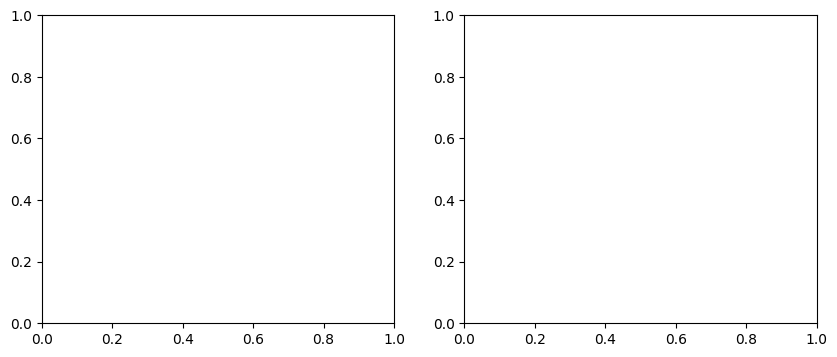

In [232]:
data = dict(
    classes=["Excelente", "Bom", "Regular", "Ruim"],
    frequencias_absolutas=[58, 18, 32, 12]    
)
fig, axs = plt.subplots(1,2, figsize=(10,4))

In [233]:
# Gráfico de barras vertical
axs[0].bar(data["classes"], data["frequencias_absolutas"])
axs[0].bar_label(axs[0].containers[0],label_type="edge")

[Text(0, 0, '58'), Text(0, 0, '18'), Text(0, 0, '32'), Text(0, 0, '12')]

In [234]:
# Gráfico de barras horizontal
axs[1].barh(data["classes"], data["frequencias_absolutas"])
axs[1].bar_label(axs[1].containers[0],label_type="edge")

[Text(0, 0, '58'), Text(0, 0, '18'), Text(0, 0, '32'), Text(0, 0, '12')]

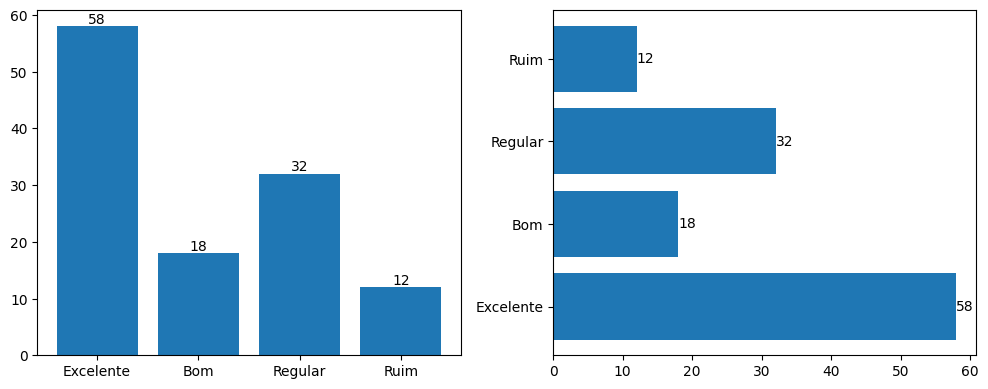

In [235]:
fig.tight_layout()
fig

## Questões propostas

### Questão 9

In [123]:
raw_data = np.array([7,5,9,11,10,8,9,6,8,10,8,5,7,11,9,11,6,7,10,9,8,5,6,8,6,7,6,5,10,8])
data = dict(vendas=np.unique(raw_data))
data["frequencia_absoluta"] = [sum(raw_data==sale) for sale in data["vendas"]]
df = pd.DataFrame(data)
df["frequencia_acumulada"] = df.frequencia_absoluta.cumsum()
df["frequencia_relativa"] = df.frequencia_absoluta/df.frequencia_absoluta.sum()
df["frequencia_relativa_acumulada"] = df.frequencia_relativa.cumsum()
df

,vendas,frequencia_absoluta,frequencia_acumulada,frequencia_relativa,frequencia_relativa_acumulada
0,5,4,4,0.133333,0.133333
1,6,5,9,0.166667,0.300000
2,7,4,13,0.133333,0.433333
3,8,6,19,0.200000,0.633333
4,9,4,23,0.133333,0.766667
5,10,4,27,0.133333,0.900000
6,11,3,30,0.100000,1.000000


### Questão 10

In [120]:
raw_data = np.array([
    60.4,78.9,65.7,82.1,80.9,92.3,85.7,86.6,90.3,93.2,
    75.2,77.3,80.4,62.,90.4,70.4,80.5,75.9,55.,84.3,
    81.3,78.3,70.5,85.6,71.9,77.5,76.1,67.7,80.6,78,
    71.6,74.8,92.1,87.7,83.8,93.4,69.3,97.8,81.7,72.2,
    69.3,80.2,90.,76.9,54.7,78.4,55.2,75.5,99.3,66.7
])
numero_classes_sturges = int(np.ceil(1+3.3*np.log10(raw_data.size)))
frequencia_absoluta, classes = np.histogram(raw_data, numero_classes_sturges)
h = classes[1]-classes[0]
classes = [f"{round(classe,2)} \u22A2 {round(classe+h,2)}" for classe in classes]
classes.pop()
data = dict(classe=classes, frequencia_absoluta=frequencia_absoluta)
df = pd.DataFrame(data)
df["frequencia_acumulada"] = df.frequencia_absoluta.cumsum()
df["frequencia_relativa"] = df.frequencia_absoluta/df.frequencia_absoluta.sum()
df["frequencia_relativa_acumulada"] = df.frequencia_relativa.cumsum()
df

,classe,frequencia_absoluta,frequencia_acumulada,frequencia_relativa,frequencia_relativa_acumulada
0,54.7 ⊢ 61.07,4,4,0.08,0.08
1,61.07 ⊢ 67.44,3,7,0.06,0.14
2,67.44 ⊢ 73.81,8,15,0.16,0.30
3,73.81 ⊢ 80.19,12,27,0.24,0.54
4,80.19 ⊢ 86.56,12,39,0.24,0.78
5,86.56 ⊢ 92.93,7,46,0.14,0.92
6,92.93 ⊢ 99.3,4,50,0.08,1.00


### Questão 11

In [124]:
data = dict(
    falha=["Desalinhamento","Risco","Deformacao","Desbotamento","Oxigenacao"],
    frequencia_absoluta=[98,67,45,28,12]
)
df = pd.DataFrame(data)
df["frequencia_acumulada"] = df.frequencia_absoluta.cumsum()
df["frequencia_relativa"] = df.frequencia_absoluta/df.frequencia_absoluta.sum()
df["frequencia_relativa_acumulada"] = df.frequencia_relativa.cumsum()
df

,falha,frequencia_absoluta,frequencia_acumulada,frequencia_relativa,frequencia_relativa_acumulada
0,Desalinhamento,98,98,0.392,0.392
1,Risco,67,165,0.268,0.660
2,Deformacao,45,210,0.180,0.840
3,Desbotamento,28,238,0.112,0.952
4,Oxigenacao,12,250,0.048,1.000


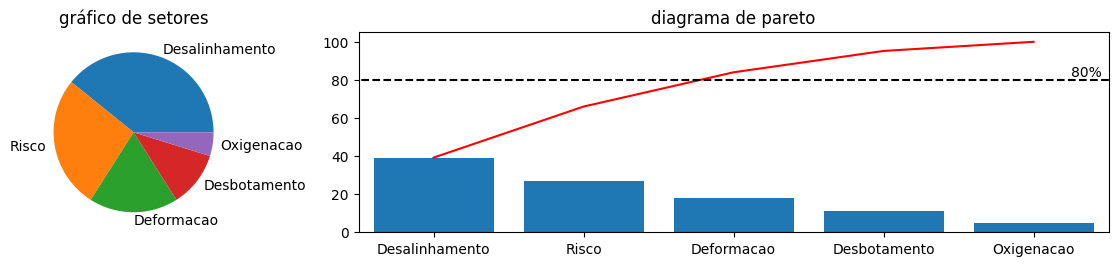

In [196]:
fig = plt.Figure(figsize=(15,2))
ax1, ax2 = fig.add_axes([0.1,1,0.4,1], title="gráfico de setores"), fig.add_axes([0.45,1,0.5,1], title="diagrama de pareto")
ax1.pie(df.frequencia_relativa, labels=df.falha)
ax2.set_xlim(-0.5,4.5)
ax2.bar(df.falha, 100*df.frequencia_relativa)
ax2.plot(df.falha, 100*df.frequencia_relativa_acumulada, c="r")
ax2.text(4.25, 82, "80%")
ax2.hlines(80, -1, 5, color="black", linestyles="--")
fig

### Questão 12

Inicialmente, importamos os dados para nossa memória RAM. Como são apenas 2kB, isso não deve ser um problema.


In [30]:
db_path = os.path.join(os.getcwd(),"data/chap02/dbs/desidratacao.csv")
df = pd.read_csv(db_path, sep=";", header=None, names=["processo"], usecols=[0], decimal=",")

#### Item a

Podemos determinar a média utilizando do método mean da classe [pd.Series](https://pandas.pydata.org/docs/reference/api/pandas.Series.html)

In [31]:
df.processo.mean()

np.float64(9.2705)

Para acharmos a mediana, iremos continuar utilizando dos métodos da mesma classe citada acima. Inicialmente ordenamos a lista de tempos, resetamos os índices para seguirem a nova ordem e então, como temos um número par de elementos (0, 1, ..., 99) fazemos a média entre os 2 valores centrais.

In [32]:
df.processo.sort_values().reset_index(drop=True)[49:51].mean()

np.float64(8.685)

Por fim, vamos determinar a moda. Inicialmente utilizamos da função [unique](https://numpy.org/doc/stable/reference/generated/numpy.unique.html) para termos acesso aos valores únicos do nosso set e a sua frequência absoluta, essas informações que são referenciadas nas variáveis vals e frqs, respectivamente. Por fim, filtramos todos os valores de vals que não tem frequência absoluta igual à máxima do conjunto.  

In [33]:
vals, frqs = np.unique(df.processo, return_counts=True)
[float(dt[0]) for dt in filter(lambda data:data[1]==frqs.max(), zip(vals,frqs))]

[5.12, 5.97, 6.18, 7.0, 7.22, 7.3, 7.48, 8.47, 8.73, 9.07, 10.25, 12.4, 15.0]

#### Item b

Inicialmente definimos os quartis a partir do método [pd.Series.quantile](https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html) e referenciamos tais valores pelas variáveis $q_1$ e $q_3$. Posteriormente calcumos a amplitude interquartil, AIQ, e então filtramos as observações que estão dentro do espaço $[q_1-1.5 \times AIQ; q_3+1.5 \times AIQ]$.

In [34]:
q1, q3 = df.processo.quantile([.25,.75]).values
AIQ = q3-q1
lower, upper= q1-1.5*AIQ, q3+1.5*AIQ
df.loc[((df.processo<lower) | (df.processo>upper)),:]

,processo
62,19.32
82,23.37


#### Item c

Dessa vez utilizamos a função percentile da numpy, visto que a classe pd.Series não tem um método específico para isso. Veja que os nossos resultados distoam do gabarito, porém uma rápida verificada do arquivo original nos faz perceber que não existem registros próximos aos reportados como resposta. 

In [35]:
np.percentile(df.processo, [9,10]).mean()

np.float64(5.336)

Letra d

De forma similar, definimos os decis a partir dos percentis 30 e 60. Novamente encontramos o mesmo distoar do gabarito.

In [36]:
np.percentile(df.processo, [30, 60])

array([7.178, 9.418])